# Prep

In [54]:
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold, KFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, precision_score, recall_score, f1_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

# Генерируем данные

In [55]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

np.random.seed(42)
N = 1200

In [56]:
# Пол: 1 = мужчина, 0 = женщина
isMale = np.random.binomial(1, 0.50, N)

# Опыт работы (лет), от 0 до 40
experience = np.clip(np.random.normal(10, 5, N), 0, 40)

# Образование (лет обучения), обрезан до [8, 22]
education = np.clip(np.random.normal(14, 3, N), 8, 22)

# Проживание в областном центре: 1 = да, 0 = нет
isUrban = np.random.binomial(1, 0.60, N)

# Инструмент: возраст 50+: 1 = да, 0 = нет
isAge50 = np.random.binomial(1, 0.30, N)

# Ненаблюдаемая мотивация (стандартная нормаль)
motivation = np.random.normal(0, 1, N)

log_odds_training = (
    -1.2
    + 0.8  * isAge50        
    + 0.5  * motivation   
    + 0.1  * education    
    + 0.2  * isUrban        
)
p_training = 1 / (1 + np.exp(-log_odds_training))
training = np.random.binomial(1, p_training, N)

# Логарифм зарплаты — линейная функция всех факторов
eps = np.random.normal(0, 0.15, N)

ln_wage = (
    6.5
    + 0.08 * training
    + 0.02 * experience
    + 0.06 * education
    + 0.15 * isMale
    + 0.12 * isUrban 
    + 0.10 * motivation
    + eps
)

wage = np.exp(ln_wage)

df = pd.DataFrame({
    "wage":        wage.round(2), 
    "training":    training, 
    "isMale":      isMale, 
    "experience":  experience.round(1), 
    "education":   education.round(1), 
    "isUrban":     isUrban, 
    "isAge50":       isAge50, 
    "motivation":  motivation.round(4), 
})



In [57]:
train_df, test_df = train_test_split(df, test_size=0.25, random_state=42)

---

# 3 

In [58]:
TEST_SIZE = 0.25
RANDOM_STATE = 42
CV_FOLDS = 5

In [59]:
FEATURE_COLS = ["isMale", "experience", "education", "isUrban", "isAge50"]

y_train = train_df["training"]
x_train = train_df[FEATURE_COLS]
y_test  = test_df["training"]
x_test  = test_df[FEATURE_COLS]

scaler     = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc  = scaler.transform(x_test)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

In [60]:
def get_Xy(scaled: bool):
    return (x_train_sc, x_test_sc) if scaled else (x_train, x_test)
 
def compute_profit(y_true, proba, threshold):
    preds = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return tp*TP_VALUE + tn*TN_VALUE + fp*FP_VALUE + fn*FN_VALUE

## 3.2

In [61]:
models_config = {
    "Logistic Regression": {
        "estimator":     LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        "default_params": {"C": 1.0},
        "param_grid":    {"C": [0.001, 0.01, 0.1, 1, 10, 100]},
        "scaled":        True,
    },
    "KNN": {
        "estimator":     KNeighborsClassifier(),
        "default_params": {"n_neighbors": 5},
        "param_grid":    {"n_neighbors": [3, 5, 10, 15, 20, 30, 50]},
        "scaled":        True,
    },
    "Random Forest (CV)": {
        "estimator":     RandomForestClassifier(random_state=RANDOM_STATE),
        "default_params": {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1},
        "param_grid":    {
            "n_estimators":    [100, 200],
            "max_depth":       [None, 5, 10],
            "min_samples_leaf":[1, 5],
        },
        "scaled": False,
    },
    "Gradient Boosting": {
        "estimator":     GradientBoostingClassifier(random_state=RANDOM_STATE),
        "default_params": {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 3},
        "param_grid":    {
            "n_estimators":  [100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth":     [3, 5],
        },
        "scaled": False,
    },
    "Naive Bayes": {
        "estimator":     GaussianNB(),
        "default_params": {},
        "param_grid":    {"var_smoothing": [1e-9, 1e-7, 1e-5, 1e-3]},
        "scaled":        False,
    },
}
 
results = {}
 
for name, cfg in models_config.items():
    Xtr, Xte = get_Xy(cfg["scaled"])
 
    # --- Default ---
    est_def = cfg["estimator"].__class__(**{
        **cfg["estimator"].get_params(),
        **cfg["default_params"]
    })
    est_def.fit(Xtr, y_train)
    cv_acc_def   = cross_val_score(est_def, Xtr, y_train, cv=cv, scoring="accuracy").mean()
    test_acc_def = accuracy_score(y_test, est_def.predict(Xte))
 
    # --- Tuned ---
    gs = GridSearchCV(
        cfg["estimator"].__class__(**cfg["estimator"].get_params()),
        cfg["param_grid"],
        cv=cv, scoring="accuracy", n_jobs=-1
    )
    gs.fit(Xtr, y_train)
    best_est      = gs.best_estimator_
    cv_acc_tuned  = gs.best_score_
    test_acc_tuned = accuracy_score(y_test, best_est.predict(Xte))
 
    results[name] = {
        "default_params":  cfg["default_params"],
        "best_params":     gs.best_params_,
        "cv_acc_default":  round(cv_acc_def,   4),
        "test_acc_default":round(test_acc_def,  4),
        "cv_acc_tuned":    round(cv_acc_tuned,   4),
        "test_acc_tuned":  round(test_acc_tuned, 4),
        "model":           best_est,
        "scaled":          cfg["scaled"],
    }
 
    print(f"\n{name}")
    print(f"  Default: CV={cv_acc_def:.4f}, Test={test_acc_def:.4f}  | params={cfg['default_params']}")
    print(f"  Tuned:   CV={cv_acc_tuned:.4f}, Test={test_acc_tuned:.4f}  | best={gs.best_params_}")
 
acc_table = pd.DataFrame([{
    "Модель":            k,
    "Default params":    str(v["default_params"]),
    "Best params":       str(v["best_params"]),
    "CV ACC (default)":  v["cv_acc_default"],
    "Test ACC (default)":v["test_acc_default"],
    "CV ACC (tuned)":    v["cv_acc_tuned"],
    "Test ACC (tuned)":  v["test_acc_tuned"],
} for k, v in results.items()])
print("\n\nСВОДНАЯ ТАБЛИЦА 3.2:\n")
print(acc_table.to_string(index=False))


Logistic Regression
  Default: CV=0.6444, Test=0.6133  | params={'C': 1.0}
  Tuned:   CV=0.6444, Test=0.6433  | best={'C': 0.01}

KNN
  Default: CV=0.5822, Test=0.5200  | params={'n_neighbors': 5}
  Tuned:   CV=0.6344, Test=0.5667  | best={'n_neighbors': 15}

Random Forest (CV)
  Default: CV=0.5811, Test=0.5733  | params={'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1}
  Tuned:   CV=0.6456, Test=0.6133  | best={'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}

Gradient Boosting
  Default: CV=0.6156, Test=0.5667  | params={'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3}
  Tuned:   CV=0.6344, Test=0.5600  | best={'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Naive Bayes
  Default: CV=0.6500, Test=0.6300  | params={}
  Tuned:   CV=0.6500, Test=0.6300  | best={'var_smoothing': 1e-09}


СВОДНАЯ ТАБЛИЦА 3.2:

             Модель                                                  Default params                                                 

## 3.3

In [62]:
TP_VALUE = 500
TN_VALUE = 100
FP_VALUE = -200
FN_VALUE = -300

def profit_score_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (TP_VALUE*tp + TN_VALUE*tn + FP_VALUE*fp + FN_VALUE*fn) / len(y_true)
 
f1_rows = []
for name, info in results.items():
    Xtr, Xte = get_Xy(info["scaled"])
    cv_f1    = cross_val_score(info["model"], Xtr, y_train, cv=cv, scoring="f1").mean()
    test_f1  = f1_score(y_test, info["model"].predict(Xte))
    test_ps  = profit_score_metric(y_test, info["model"].predict(Xte))
    f1_rows.append({
        "Модель":            name,
        "CV F1 (tuned)":     round(cv_f1,   4),
        "Test F1 (tuned)":   round(test_f1,  4),
        "Test ACC (tuned)":  info["test_acc_tuned"],
        "Profit score (test)": round(test_ps, 4),
    })
 
f1_table = pd.DataFrame(f1_rows)
print(f1_table.to_string(index=False))

             Модель  CV F1 (tuned)  Test F1 (tuned)  Test ACC (tuned)  Profit score (test)
Logistic Regression         0.7820           0.7794            0.6433             244.0000
                KNN         0.7517           0.7005            0.5667             159.3333
 Random Forest (CV)         0.7683           0.7422            0.6133             198.3333
  Gradient Boosting         0.7544           0.6944            0.5600             154.0000
        Naive Bayes         0.7630           0.7483            0.6300             200.0000


## 3.4

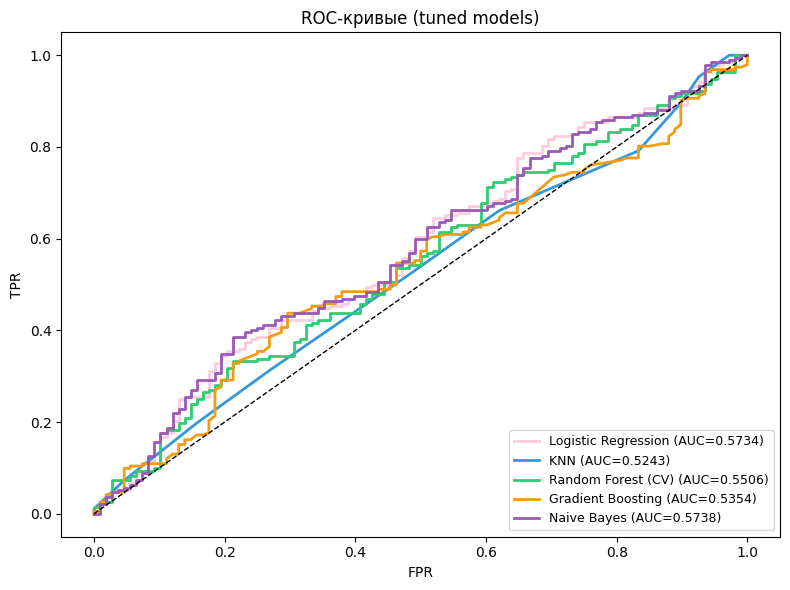

             Модель    AUC
        Naive Bayes 0.5738
Logistic Regression 0.5734
 Random Forest (CV) 0.5506
  Gradient Boosting 0.5354
                KNN 0.5243


In [63]:
plt.figure(figsize=(8, 6))
colors = ["#FDCCE1", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]
 
auc_rows = []
for i, (name, info) in enumerate(results.items()):
    _, Xte = get_Xy(info["scaled"])
    proba  = info["model"].predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f"{name} (AUC={auc:.4f})")
    auc_rows.append({"Модель": name, "AUC": round(auc, 4)})
 
plt.plot([0,1],[0,1], "k--", lw=1)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC-кривые (tuned models)")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()
# plt.savefig("roc_curves.png", dpi=150)
# plt.close()
# print("ROC сохранён: roc_curves.png")
print(pd.DataFrame(auc_rows).sort_values("AUC", ascending=False).to_string(index=False))

## 3.5


Лучшая модель по AUC: Naive Bayes

Матрица ошибок (порог=0.5):
           Pred=0    Pred=1
True=0     TN=  24   FP=  84
True=1     FN=  27   TP= 165

Accuracy:  0.6300
Precision: 0.6627
Recall:    0.8594
F1:        0.7483


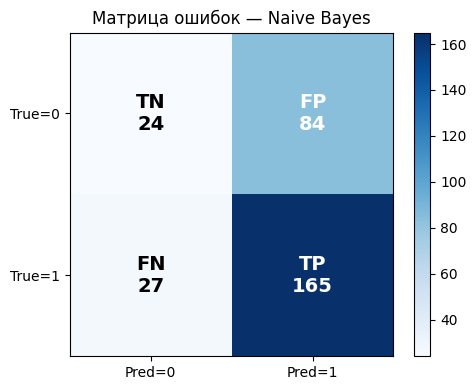

In [64]:
best_name = max(auc_rows, key=lambda r: r["AUC"])["Модель"]
best_info = results[best_name]
_, Xte_best = get_Xy(best_info["scaled"])
y_pred_best = best_info["model"].predict(Xte_best)
 
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
 
print(f"\nЛучшая модель по AUC: {best_name}")
print(f"\nМатрица ошибок (порог=0.5):")
print(f"           Pred=0    Pred=1")
print(f"True=0     TN={tn:4d}   FP={fp:4d}")
print(f"True=1     FN={fn:4d}   TP={tp:4d}")
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_best):.4f}")
 
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Pred=0","Pred=1"]); ax.set_yticklabels(["True=0","True=1"])
labels = [["TN","FP"],["FN","TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n{cm[i,j]}", ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=14, fontweight="bold")
ax.set_title(f"Матрица ошибок — {best_name}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 3.6

In [65]:
proba_best = best_info["model"].predict_proba(Xte_best)[:, 1]
 
thresh_rows = []
for thresh in [0.3, 0.5, 0.7]:
    preds = (proba_best >= thresh).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, preds).ravel()
    thresh_rows.append({
        "Порог":    thresh,
        "ACC":      round(accuracy_score(y_test, preds), 4),
        "Precision":round(precision_score(y_test, preds, zero_division=0), 4),
        "Recall":   round(recall_score(y_test, preds, zero_division=0), 4),
        "F1":       round(f1_score(y_test, preds, zero_division=0), 4),
        "TP": int(tp_), "TN": int(tn_), "FP": int(fp_), "FN": int(fn_),
    })
 
thresh_df = pd.DataFrame(thresh_rows)
print(f"\nМодель: {best_name}\n")
print(thresh_df.to_string(index=False))


Модель: Naive Bayes

 Порог    ACC  Precision  Recall     F1  TP  TN  FP  FN
   0.3 0.6400     0.6400  1.0000 0.7805 192   0 108   0
   0.5 0.6300     0.6627  0.8594 0.7483 165  24  84  27
   0.7 0.4833     0.7467  0.2917 0.4195  56  89  19 136


## 3.7



             Модель  Опт. порог (train)  Прибыль (порог=0.5)  Прибыль (опт. порог)  Прирост
                KNN                0.27                47800                 75300    27500
        Naive Bayes                0.39                60000                 74400    14400
Logistic Regression                0.50                73200                 73200        0
 Random Forest (CV)                0.47                59500                 64000     4500
  Gradient Boosting                0.48                46200                 55300     9100


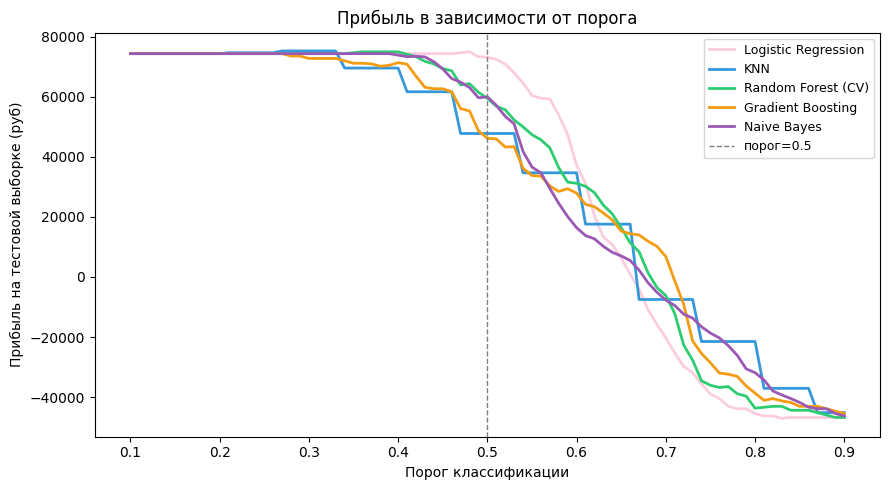

In [66]:
thresholds_scan = np.arange(0.10, 0.91, 0.01)
profit_rows = []
 
for name, info in results.items():
    Xtr, Xte = get_Xy(info["scaled"])
    proba_tr  = info["model"].predict_proba(Xtr)[:, 1]
    proba_te  = info["model"].predict_proba(Xte)[:, 1]
 
    best_thr = max(thresholds_scan,
                   key=lambda t: compute_profit(y_train, proba_tr, t))
 
    profit_05  = compute_profit(y_test, proba_te, 0.50)
    profit_opt = compute_profit(y_test, proba_te, best_thr)
 
    profit_rows.append({
        "Модель":               name,
        "Опт. порог (train)":   round(float(best_thr), 2),
        "Прибыль (порог=0.5)":  profit_05,
        "Прибыль (опт. порог)": profit_opt,
        "Прирост":              profit_opt - profit_05,
    })
 
profit_df = pd.DataFrame(profit_rows).sort_values("Прибыль (опт. порог)", ascending=False)
print("\n")
print(profit_df.to_string(index=False))
 
plt.figure(figsize=(9, 5))
for i, (name, info) in enumerate(results.items()):
    _, Xte = get_Xy(info["scaled"])
    proba_te = info["model"].predict_proba(Xte)[:, 1]
    profits  = [compute_profit(y_test, proba_te, t) for t in thresholds_scan]
    plt.plot(thresholds_scan, profits, color=colors[i], lw=2, label=name)
 
plt.axvline(0.5, color="grey", ls="--", lw=1, label="порог=0.5")
plt.xlabel("Порог классификации")
plt.ylabel("Прибыль на тестовой выборке (руб)")
plt.title("Прибыль в зависимости от порога")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3.8

In [67]:
from pgmpy.causal_discovery import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

In [68]:
tuned_models = {
    "Logistic Regression": (LogisticRegression(C=0.01, random_state=RANDOM_STATE, max_iter=1000), True),
    "KNN":                 (KNeighborsClassifier(n_neighbors=30), True),
    "Random Forest":       (RandomForestClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE), False),
    "Gradient Boosting":   (GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE), False),
    "Naive Bayes":         (GaussianNB(), False),
}
 
def profit_metric(y_true, preds):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return tp*TP_VALUE + tn*TN_VALUE + fp*FP_VALUE + fn*FN_VALUE

sklearn_results = {}
for name, info in results.items():
    Xtr, Xte = get_Xy(info["scaled"])
    proba_tr = info["model"].predict_proba(Xtr)[:, 1]
    proba_te = info["model"].predict_proba(Xte)[:, 1]

    best_thr = max(thresholds_scan,
                   key=lambda t: compute_profit(y_train, proba_tr, t))

    preds_opt = (proba_te >= best_thr).astype(int)

    sklearn_results[name] = {
        "model":       info["model"],
        "scaled":      info["scaled"],
        "test_acc":    round(accuracy_score(y_test, preds_opt), 4),
        "test_f1":     round(f1_score(y_test, preds_opt), 4),
        "test_auc":    round(roc_auc_score(y_test, proba_te), 4),
        "test_profit": compute_profit(y_test, proba_te, best_thr),
        "best_thr":    round(float(best_thr), 2),
        "proba":       proba_te,
        "preds":       preds_opt,
    }


Переменные после дискретизации: ['isMale', 'isUrban', 'isAge50', 'training', 'educ_bin', 'exp_bin']

Ручной DAG, рёбра: [('isAge50', 'training'), ('educ_bin', 'training'), ('isUrban', 'training')]
Ручной BN обучен ✓

Обучаю структуру (Hill Climb, BIC-d)...
Обученные рёбра: [('training', 'isAge50'), ('training', 'educ_bin')]
Обученный BN обучен

Вычисляю вероятности (это займёт минуту)...

Модель                         ACC      AUC
Ручной DAG                  0.6467   0.5468
Обученный DAG               0.6400   0.5516


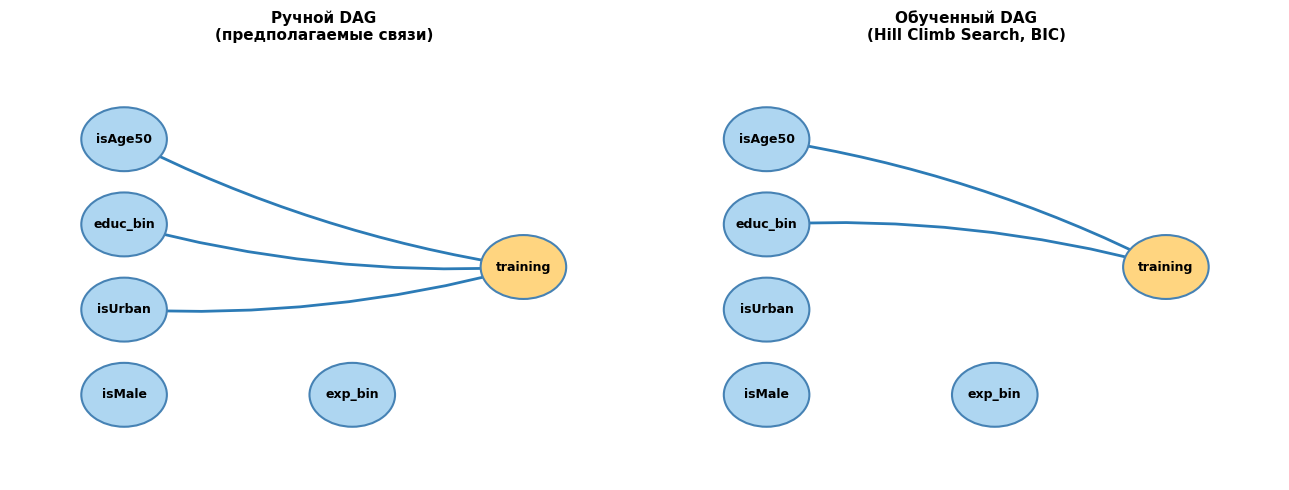

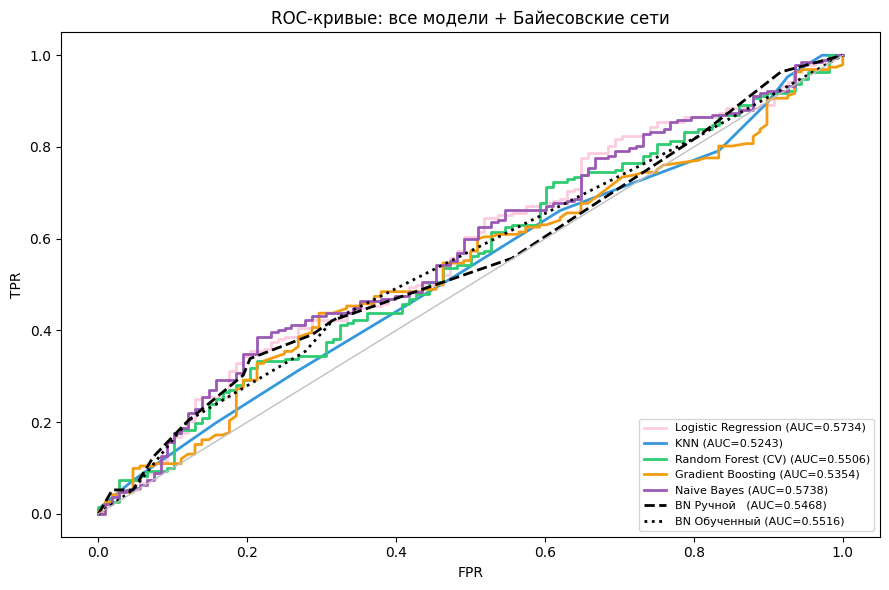

In [69]:
def discretize(df_in):
    d = df_in.copy()
    d["educ_bin"] = pd.cut(d["education"], bins=[0,12,16,30],
                           labels=["low","mid","high"]).astype(str)
    d["exp_bin"]  = pd.cut(d["experience"], bins=[-1,5,15,50],
                           labels=["low","mid","high"]).astype(str)
    return d.drop(columns=["education","experience"])
 
train_disc = discretize(pd.concat([x_train, y_train], axis=1))
test_disc  = discretize(pd.concat([x_test,  y_test],  axis=1))
for col in train_disc.columns:
    train_disc[col] = train_disc[col].astype(str)
    test_disc[col] = test_disc[col].astype(str)
 
print("\nПеременные после дискретизации:", list(train_disc.columns))
 

MANUAL_EDGES = [
    ("isAge50", "training"),
    ("educ_bin", "training"),
    ("isUrban", "training"),
]
print("\nРучной DAG, рёбра:", MANUAL_EDGES)
 
bn_manual = DiscreteBayesianNetwork(ebunch=MANUAL_EDGES)
for col in train_disc.columns:
    if col not in bn_manual.nodes():
        bn_manual.add_node(col)
est = BayesianEstimator(bn_manual, train_disc)
bn_manual.add_cpds(*[est.estimate_cpd(n, prior_type="BDeu", equivalent_sample_size=5)
                     for n in bn_manual.nodes()])
print("Ручной BN обучен ✓")
 
print("\nОбучаю структуру (Hill Climb, BIC-d)...")
hc = HillClimbSearch(scoring_method="bic-d", max_indegree=3,
                     return_type="dag", show_progress=False)
hc.fit(train_disc)
learned_edges = list(hc.causal_graph_.edges())
print("Обученные рёбра:", learned_edges)
 
bn_learned = DiscreteBayesianNetwork(ebunch=learned_edges if learned_edges else None)
for col in train_disc.columns:
    if col not in bn_learned.nodes():
        bn_learned.add_node(col)
est2 = BayesianEstimator(bn_learned, train_disc)
bn_learned.add_cpds(*[est2.estimate_cpd(n, prior_type="BDeu", equivalent_sample_size=5)
                      for n in bn_learned.nodes()])
print("Обученный BN обучен")
 
def bn_predict_proba(bn, test_data, target="training"):
    infer = VariableElimination(bn)
    probas = []
    ev_cols = [c for c in test_data.columns if c != target]
    for _, row in test_data[ev_cols].iterrows():
        try:
            q = infer.query([target], evidence=row.to_dict(), show_progress=False)
            states = list(q.state_names[target])
            idx = states.index("1") if "1" in states else 0
            probas.append(float(q.values[idx]))
        except Exception:
            probas.append(0.5)
    return np.array(probas)
 
print("\nВычисляю вероятности (это займёт минуту)...")
proba_manual  = bn_predict_proba(bn_manual,  test_disc)
proba_learned = bn_predict_proba(bn_learned, test_disc)
 
y_test_int = (test_disc["training"] == "1").astype(int).values
acc_manual  = accuracy_score(y_test_int, (proba_manual  >= 0.5).astype(int))
acc_learned = accuracy_score(y_test_int, (proba_learned >= 0.5).astype(int))
auc_manual  = roc_auc_score(y_test_int, proba_manual)
auc_learned = roc_auc_score(y_test_int, proba_learned)
 
print(f"\n{'Модель':<25} {'ACC':>8} {'AUC':>8}")
print(f"{'Ручной DAG':<25} {acc_manual:>8.4f} {auc_manual:>8.4f}")
print(f"{'Обученный DAG':<25} {acc_learned:>8.4f} {auc_learned:>8.4f}")
 
node_pos = {
    "isAge50":    (1, 7), "educ_bin": (1, 5), "isUrban":    (1, 3),
    "isMale":     (1, 1), "exp_bin":  (5, 1), "training": (8, 4),
}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, edges, title in [
    (axes[0], MANUAL_EDGES,   "Ручной DAG\n(предполагаемые связи)"),
    (axes[1], learned_edges,  "Обученный DAG\n(Hill Climb Search, BIC)"),
]:
    ax.set_xlim(-1, 10); ax.set_ylim(-1, 9); ax.axis("off")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    for u, v in edges:
        if u in node_pos and v in node_pos:
            x0,y0 = node_pos[u]; x1,y1 = node_pos[v]
            ax.annotate("", xy=(x1,y1), xytext=(x0,y0),
                        arrowprops=dict(arrowstyle="->", color="#2c7bb6",
                                        lw=2, connectionstyle="arc3,rad=0.08"))
    for node, (x, y) in node_pos.items():
        col = "#FFD580" if node == "training" else "#AED6F1"
        circle = plt.Circle((x, y), 0.75, color=col, zorder=5, ec="steelblue", lw=1.5)
        ax.add_patch(circle)
        ax.text(x, y, node, ha="center", va="center", fontsize=9,
                fontweight="bold", zorder=6)
    if not edges:
        ax.text(4.5, 4, "Нет рёбер\n(алгоритм не нашёл\nзначимых связей)",
                ha="center", va="center", fontsize=10, color="gray",
                style="italic")
plt.tight_layout()
plt.show()
# plt.savefig("dag_comparison.png", dpi=150, bbox_inches="tight")
# plt.close()
# print("DAG-диаграмма → dag_comparison.png")
 

colors_roc = ["#FDCCE1","#3498db","#2ecc71","#f39c12","#9b59b6"]
plt.figure(figsize=(9, 6))
for i, (name, info) in enumerate(sklearn_results.items()):
    fpr, tpr, _ = roc_curve(y_test, info["proba"])
    plt.plot(fpr, tpr, color=colors_roc[i], lw=2,
             label=f"{name} (AUC={info['test_auc']:.4f})")
fpr_m, tpr_m, _ = roc_curve(y_test_int, proba_manual)
fpr_l, tpr_l, _ = roc_curve(y_test_int, proba_learned)
plt.plot(fpr_m, tpr_m, "k--",  lw=2, label=f"BN Ручной   (AUC={auc_manual:.4f})")
plt.plot(fpr_l, tpr_l, "k:",   lw=2, label=f"BN Обученный (AUC={auc_learned:.4f})")
plt.plot([0,1],[0,1], "silver", lw=1)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC-кривые: все модели + Байесовские сети")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()
# plt.savefig("roc_with_bn.png", dpi=150)
# plt.close()
# print("ROC → roc_with_bn.png")

## 3.9


СВОДНАЯ ТАБЛИЦА:

             Модель    ACC     F1    AUC  Profit (руб)
        Naive Bayes 0.6400 0.7805 0.5738       74400.0
Logistic Regression 0.6433 0.7794 0.5734       73200.0
   BN Обученный DAG 0.6400 0.7805 0.5516       74400.0
 Random Forest (CV) 0.6133 0.7521 0.5506       64000.0
      BN Ручной DAG 0.6467 0.7773 0.5468       71500.0
  Gradient Boosting 0.5833 0.7241 0.5354       55300.0
                KNN 0.6500 0.7853 0.5243       75300.0

── Составной критерий (AUC×0.4 + Profit×0.4 + F1×0.2) ──
             Модель    AUC     F1  Profit (руб)    score
        Naive Bayes 0.5738 0.7805       74400.0 0.966314
Logistic Regression 0.5734 0.7794       73200.0 0.935487
   BN Обученный DAG 0.5516 0.7805       74400.0 0.786920
      BN Ручной DAG 0.5468 0.7773       71500.0 0.679674
                KNN 0.5243 0.7853       75300.0 0.600000
 Random Forest (CV) 0.5506 0.7521       64000.0 0.478029
  Gradient Boosting 0.5354 0.7241       55300.0 0.089697

Лучшая модель: Naive Bayes

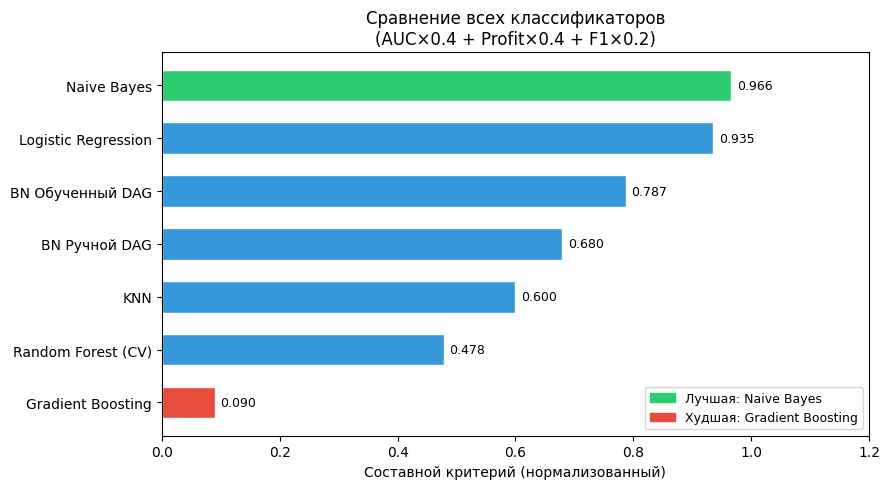

In [70]:
all_models = {}
for name, info in sklearn_results.items():
    all_models[name] = {
        "ACC":    info["test_acc"],
        "F1":     info["test_f1"],
        "AUC":    info["test_auc"],
        "Profit": info["test_profit"],
    }
all_models["BN Ручной DAG"] = {
    "ACC":    round(acc_manual,  4),
    "F1":     round(f1_score(y_test_int, (proba_manual  >= 0.5).astype(int)), 4),
    "AUC":    round(auc_manual,  4),
    "Profit": profit_metric(y_test_int, (proba_manual  >= 0.5).astype(int)),
}
all_models["BN Обученный DAG"] = {
    "ACC":    round(acc_learned, 4),
    "F1":     round(f1_score(y_test_int, (proba_learned >= 0.5).astype(int)), 4),
    "AUC":    round(auc_learned, 4),
    "Profit": profit_metric(y_test_int, (proba_learned >= 0.5).astype(int)),
}
 
summary = pd.DataFrame(all_models).T.reset_index()
summary.columns = ["Модель", "ACC", "F1", "AUC", "Profit (руб)"]
print("\nСВОДНАЯ ТАБЛИЦА:\n")
print(summary.sort_values("AUC", ascending=False).to_string(index=False))
 
# Составной критерий: AUC×0.4 + Profit×0.4 + F1×0.2
for col, key in [("AUC","n_auc"),("Profit (руб)","n_profit"),("F1","n_f1")]:
    mn, mx = summary[col].min(), summary[col].max()
    summary[key] = (summary[col] - mn) / (mx - mn + 1e-9)
summary["score"] = 0.4*summary["n_auc"] + 0.4*summary["n_profit"] + 0.2*summary["n_f1"]
 
best  = summary.loc[summary["score"].idxmax(), "Модель"]
worst = summary.loc[summary["score"].idxmin(), "Модель"]
 
print("\n── Составной критерий (AUC×0.4 + Profit×0.4 + F1×0.2) ──")
print(summary[["Модель","AUC","F1","Profit (руб)","score"]]
      .sort_values("score", ascending=False).to_string(index=False))
print(f"\nЛучшая модель: {best}")
print(f"Худшая модель:  {worst}")
 
# График
fig, ax = plt.subplots(figsize=(9, 5))
s = summary.sort_values("score", ascending=True)
bar_colors = ["#e74c3c" if m==worst else "#2ecc71" if m==best else "#3498db"
              for m in s["Модель"]]
bars = ax.barh(s["Модель"], s["score"], color=bar_colors, edgecolor="white", height=0.6)
for bar, val in zip(bars, s["score"]):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
ax.set_xlabel("Составной критерий (нормализованный)")
ax.set_title("Сравнение всех классификаторов\n(AUC×0.4 + Profit×0.4 + F1×0.2)")
ax.set_xlim(0, 1.2)
handles = [mpatches.Patch(color="#2ecc71", label=f"Лучшая: {best}"),
           mpatches.Patch(color="#e74c3c", label=f"Худшая: {worst}")]
ax.legend(handles=handles, fontsize=9)
plt.tight_layout()
plt.show()

In [71]:
print(compute_profit.__code__.co_code == profit_metric.__code__.co_code)

False


# 4

## 4.1

Зависимая переменная: wage (непрерывная) <br>
Исключаем: training (переменная воздействия!) и motivation (ненаблюдаемая)<br>
Признаки: isMale, experience, education, isUrban, isAge50

In [72]:
y_train_reg = train_df["wage"]
x_train_reg = train_df.drop(columns=["wage"])
y_test_reg = test_df["wage"]
x_test_reg = test_df.drop(columns=["wage"])

scaler_reg = StandardScaler()
x_train_reg_sc = scaler_reg.fit_transform(x_train_reg)
x_test_reg_sc = scaler_reg.transform(x_test_reg)

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

In [73]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
 
def mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100  # в процентах
 
def cv_rmse(model, X, y, cv):
    scores = cross_val_score(model, X, y, cv=cv,
                             scoring="neg_root_mean_squared_error")
    return -scores.mean()
 
def cv_mape(model, X, y, cv):
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_percentage_error")
    return -scores.mean() * 100
 
def get_Xy_reg(scaled: bool):
    return (x_train_reg_sc, x_test_reg_sc) if scaled else (x_train_reg, x_test_reg)

## 4.2


Linear Regression (OLS)
  Default → CV RMSE=404.30, CV MAPE=13.15%, Test RMSE=426.83, Test MAPE=14.41%
  Tuned   → CV RMSE=404.30, CV MAPE=13.15%, Test RMSE=426.83, Test MAPE=14.41%
  Best params: {'fit_intercept': True, 'positive': False}

KNN Regressor
  Default → CV RMSE=482.13, CV MAPE=15.68%, Test RMSE=474.02, Test MAPE=15.40%
  Tuned   → CV RMSE=469.84, CV MAPE=15.19%, Test RMSE=466.28, Test MAPE=15.54%
  Best params: {'n_neighbors': 15, 'weights': 'distance'}

Random Forest Regressor
  Default → CV RMSE=445.62, CV MAPE=14.33%, Test RMSE=448.11, Test MAPE=14.88%
  Tuned   → CV RMSE=439.93, CV MAPE=14.16%, Test RMSE=446.93, Test MAPE=14.70%
  Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}


СВОДНАЯ ТАБЛИЦА 4.2:

                 Модель                                                  Default params                                                     Best params  CV RMSE (def)  Test RMSE (def)  CV RMSE (tuned)  Test RMSE (tuned)  CV MAPE% (def)  Test 

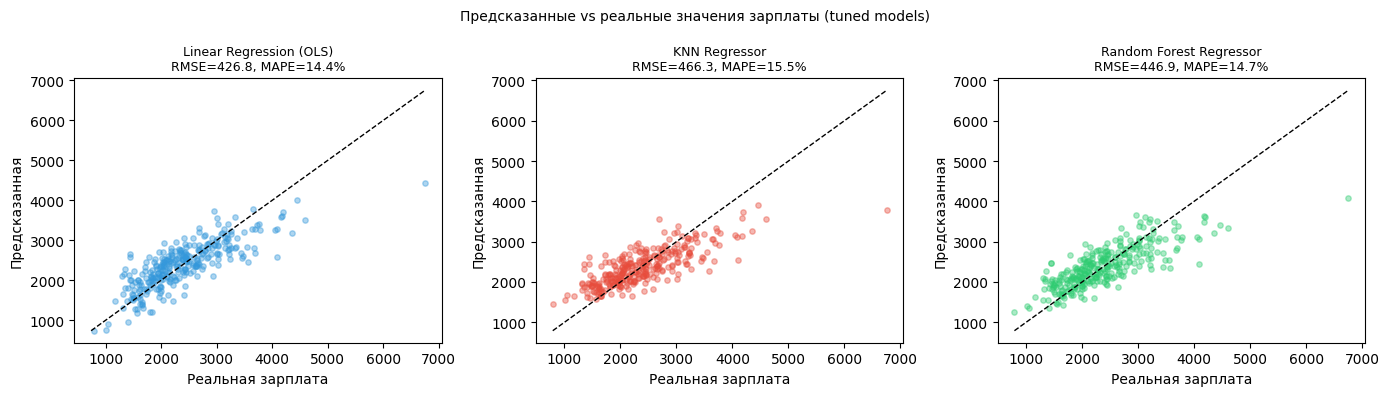

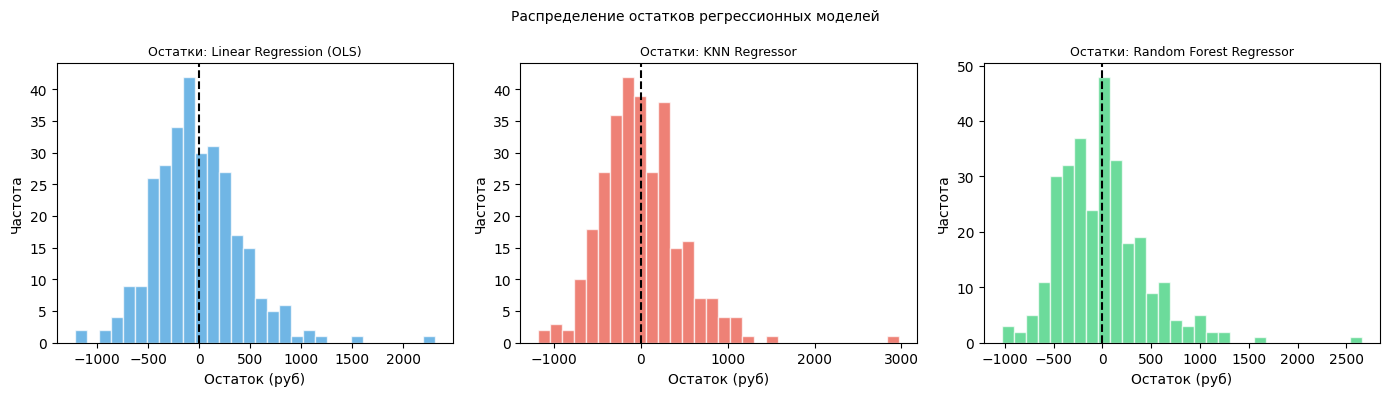

In [74]:
reg_configs = {
    "Linear Regression (OLS)": {
        "estimator":      LinearRegression(),
        "default_params": {},           # у OLS нет гиперпараметров
        "param_grid":     {"fit_intercept": [True, False],
                           "positive": [False]},   # minimal grid
        "scaled": True,
    },
    "KNN Regressor": {
        "estimator":      KNeighborsRegressor(),
        "default_params": {"n_neighbors": 5},
        "param_grid":     {"n_neighbors": [3, 5, 10, 15, 20, 30, 50],
                           "weights":     ["uniform", "distance"]},
        "scaled": True,
    },
    "Random Forest Regressor": {
        "estimator":      RandomForestRegressor(random_state=42),
        "default_params": {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1},
        "param_grid":     {"n_estimators":    [100, 200],
                           "max_depth":       [None, 5, 10],
                           "min_samples_leaf":[1, 5]},
        "scaled": False,
    },
}
 
reg_results = {}
 
for name, cfg in reg_configs.items():
    Xtr, Xte = get_Xy_reg(cfg["scaled"])
 
    est_def = cfg["estimator"].__class__(**{
        **cfg["estimator"].get_params(),
        **cfg["default_params"]
    })
    est_def.fit(Xtr, y_train_reg)
 
    cv_rmse_def  = cv_rmse(est_def, Xtr, y_train_reg, cv_reg)
    cv_mape_def  = cv_mape(est_def, Xtr, y_train_reg, cv_reg)
    test_rmse_def = rmse(y_test_reg, est_def.predict(Xte))
    test_mape_def = mape(y_test_reg, est_def.predict(Xte))
 
    gs = GridSearchCV(
        cfg["estimator"].__class__(**cfg["estimator"].get_params()),
        cfg["param_grid"],
        cv=cv_reg,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    gs.fit(Xtr, y_train_reg)
    best_est = gs.best_estimator_
 
    cv_rmse_tuned  = -gs.best_score_
    cv_mape_tuned  = cv_mape(best_est, Xtr, y_train_reg, cv_reg)
    test_rmse_tuned = rmse(y_test_reg, best_est.predict(Xte))
    test_mape_tuned = mape(y_test_reg, best_est.predict(Xte))
 
    reg_results[name] = {
        "model":            best_est,
        "scaled":           cfg["scaled"],
        "default_params":   cfg["default_params"],
        "best_params":      gs.best_params_,
        # default
        "cv_rmse_def":      round(cv_rmse_def,   2),
        "cv_mape_def":      round(cv_mape_def,   2),
        "test_rmse_def":    round(test_rmse_def,  2),
        "test_mape_def":    round(test_mape_def,  2),
        # tuned
        "cv_rmse_tuned":    round(cv_rmse_tuned,  2),
        "cv_mape_tuned":    round(cv_mape_tuned,  2),
        "test_rmse_tuned":  round(test_rmse_tuned, 2),
        "test_mape_tuned":  round(test_mape_tuned, 2),
    }
 
    print(f"\n{name}")
    print(f"  Default → CV RMSE={cv_rmse_def:.2f}, CV MAPE={cv_mape_def:.2f}%"
          f", Test RMSE={test_rmse_def:.2f}, Test MAPE={test_mape_def:.2f}%")
    print(f"  Tuned   → CV RMSE={cv_rmse_tuned:.2f}, CV MAPE={cv_mape_tuned:.2f}%"
          f", Test RMSE={test_rmse_tuned:.2f}, Test MAPE={test_mape_tuned:.2f}%")
    print(f"  Best params: {gs.best_params_}")
 
table_rows = []
for name, r in reg_results.items():
    table_rows.append({
        "Модель":               name,
        "Default params":       str(r["default_params"]),
        "Best params":          str(r["best_params"]),
        "CV RMSE (def)":        r["cv_rmse_def"],
        "Test RMSE (def)":      r["test_rmse_def"],
        "CV RMSE (tuned)":      r["cv_rmse_tuned"],
        "Test RMSE (tuned)":    r["test_rmse_tuned"],
        "CV MAPE% (def)":       r["cv_mape_def"],
        "Test MAPE% (def)":     r["test_mape_def"],
        "CV MAPE% (tuned)":     r["cv_mape_tuned"],
        "Test MAPE% (tuned)":   r["test_mape_tuned"],
    })
 
summary_table = pd.DataFrame(table_rows)
print("\n\nСВОДНАЯ ТАБЛИЦА 4.2:\n")
print(summary_table.to_string(index=False))
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_reg = ["#3498db", "#e74c3c", "#2ecc71"]
 
for ax, (name, r), col in zip(axes, reg_results.items(), colors_reg):
    _, Xte = get_Xy_reg(r["scaled"])
    y_pred = r["model"].predict(Xte)
    ax.scatter(y_test_reg, y_pred, alpha=0.4, s=15, color=col)
    mn = min(y_test_reg.min(), y_pred.min())
    mx = max(y_test_reg.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], "k--", lw=1)
    ax.set_xlabel("Реальная зарплата")
    ax.set_ylabel("Предсказанная")
    ax.set_title(f"{name}\nRMSE={r['test_rmse_tuned']:.1f}, MAPE={r['test_mape_tuned']:.1f}%",
                 fontsize=9)
 
plt.suptitle("Предсказанные vs реальные значения зарплаты (tuned models)", fontsize=10)
plt.tight_layout()
plt.show()
plt.close()
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, r), col in zip(axes, reg_results.items(), colors_reg):
    _, Xte = get_Xy_reg(r["scaled"])
    residuals = y_test_reg.values - r["model"].predict(Xte)
    ax.hist(residuals, bins=30, color=col, alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", lw=1.5, ls="--")
    ax.set_xlabel("Остаток (руб)")
    ax.set_ylabel("Частота")
    ax.set_title(f"Остатки: {name}", fontsize=9)
 
plt.suptitle("Распределение остатков регрессионных моделей", fontsize=10)
plt.tight_layout()
plt.show()

## 4.3

In [75]:
compare = pd.DataFrame([{
    "Модель":           name,
    "Test RMSE":        r["test_rmse_tuned"],
    "Test MAPE%":       r["test_mape_tuned"],
    "CV RMSE":          r["cv_rmse_tuned"],
    "Overfitting":      round(r["test_rmse_tuned"] - r["cv_rmse_tuned"], 2),
} for name, r in reg_results.items()])
 
for col, key in [("Test RMSE", "n_rmse"), ("Test MAPE%", "n_mape")]:
    mn, mx = compare[col].min(), compare[col].max()
    compare[key] = (compare[col] - mn) / (mx - mn + 1e-9)
 
compare["score"] = 0.6 * compare["n_rmse"] + 0.4 * compare["n_mape"]
compare["composite"] = 1 - compare["score"]
 
best_model  = compare.loc[compare["composite"].idxmax(), "Модель"]
worst_model = compare.loc[compare["composite"].idxmin(), "Модель"]
 
print("\n")
print(compare[["Модель","Test RMSE","Test MAPE%","CV RMSE","Overfitting","composite"]]
      .sort_values("composite", ascending=False).to_string(index=False))
print(f"\nЛучшая модель:  {best_model}")
print(f"Худшая модель:  {worst_model}")



                 Модель  Test RMSE  Test MAPE%  CV RMSE  Overfitting    composite
Linear Regression (OLS)     426.83       14.41   404.30        22.53 1.000000e+00
Random Forest Regressor     446.93       14.70   439.93         7.00 5.916417e-01
          KNN Regressor     466.28       15.54   469.84        -3.56 3.691913e-10

Лучшая модель:  Linear Regression (OLS)
Худшая модель:  KNN Regressor


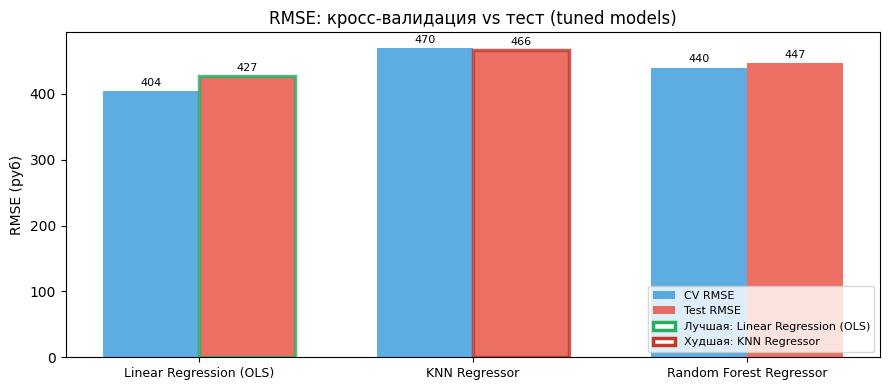

In [76]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(reg_results))
w = 0.35
names  = list(reg_results.keys())
cv_rmses   = [reg_results[n]["cv_rmse_tuned"]   for n in names]
test_rmses = [reg_results[n]["test_rmse_tuned"]  for n in names]
 
bars1 = ax.bar(x - w/2, cv_rmses,   w, label="CV RMSE",   color="#3498db", alpha=0.8)
bars2 = ax.bar(x + w/2, test_rmses, w, label="Test RMSE", color="#e74c3c", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel("RMSE (руб)")
ax.set_title("RMSE: кросс-валидация vs тест (tuned models)")
ax.legend()
 
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=8)

handles_extra = [
    mpatches.Patch(facecolor="white", edgecolor="#27ae60", lw=2.5, label=f"Лучшая: {best_model}"),
    mpatches.Patch(facecolor="white", edgecolor="#c0392b", lw=2.5, label=f"Худшая: {worst_model}"),
]

ax.legend(handles=ax.get_legend_handles_labels()[0] + handles_extra,
          labels=ax.get_legend_handles_labels()[1] + [h.get_label() for h in handles_extra],
          fontsize=8, loc="lower right")

for bar, n in zip(bars2, names):
    if n == best_model:
        bar.set_edgecolor("#27ae60"); bar.set_linewidth(2.5)
    elif n == worst_model:
        bar.set_edgecolor("#c0392b"); bar.set_linewidth(2.5)
 


plt.tight_layout()
plt.show()

---

In [77]:
df.to_csv("data_full.csv", index=False)
train_df.to_csv("data_train.csv", index=False)
test_df.to_csv("data_test.csv", index=False)

print("=" * 60)
print(f"  ДАННЫЕ СГЕНЕРИРОВАНЫ  |  N = {N}")
print("=" * 60)

print("\n НЕПРЕРЫВНЫЕ ПЕРЕМЕННЫЕ:")
cont_vars = ["wage", "experience", "education", "motivation"]
stats = df[cont_vars].agg(["mean", "std", "median", "min", "max"]).T
stats.columns = ["Mean", "Std", "Median", "Min", "Max"]
print(stats.round(2).to_string())

print("\n БИНАРНЫЕ ПЕРЕМЕННЫЕ:")
bin_vars = ["training", "isMale", "isUrban", "isAge50"]
for v in bin_vars:
    ones = df[v].sum()
    share = df[v].mean()
    print(f"  {v:<12} доля = {share:.3f}  |  единиц = {ones}  |  нулей = {N - ones}")

print("\n КОРРЕЛЯЦИОННАЯ МАТРИЦА (наблюдаемые переменные):")
obs_vars = ["wage", "training", "isMale", "experience", "education", "isUrban", "isAge50"]
print(df[obs_vars].corr().round(3).to_string())

print("\n  РАЗБИЕНИЕ ВЫБОРКИ:")
print(f"  Train: {len(train_df)} наблюдений (75%)")
print(f"  Test:  {len(test_df)} наблюдений  (25%)")

print("\n Файлы сохранены: data_full.csv | data_train.csv | data_test.csv")

  ДАННЫЕ СГЕНЕРИРОВАНЫ  |  N = 1200

 НЕПРЕРЫВНЫЕ ПЕРЕМЕННЫЕ:
               Mean     Std   Median     Min      Max
wage        2422.34  730.66  2318.02  790.63  6752.59
experience    10.28    4.86    10.15    0.00    26.00
education     14.03    2.92    14.05    8.00    22.00
motivation    -0.03    1.01    -0.05   -2.90     3.10

 БИНАРНЫЕ ПЕРЕМЕННЫЕ:
  training     доля = 0.642  |  единиц = 770  |  нулей = 430
  isMale       доля = 0.510  |  единиц = 612  |  нулей = 588
  isUrban      доля = 0.623  |  единиц = 748  |  нулей = 452
  isAge50      доля = 0.298  |  единиц = 358  |  нулей = 842

 КОРРЕЛЯЦИОННАЯ МАТРИЦА (наблюдаемые переменные):
             wage  training  isMale  experience  education  isUrban  isAge50
wage        1.000     0.296   0.274       0.319      0.611    0.150    0.040
training    0.296     1.000   0.050      -0.036      0.130    0.036    0.149
isMale      0.274     0.050   1.000       0.001      0.029    0.022   -0.013
experience  0.319    -0.036   0.001       

# 5

In [78]:
from scipy.special import expit
import seaborn as sns
full_df = pd.concat([train_df, test_df], ignore_index=True)

## 5.2

In [79]:
np.random.seed(42)
N_oracle = 2_000_000

motivation_o = np.random.normal(0, 1, N_oracle)
isAge50_o    = np.random.binomial(1, 0.3, N_oracle)
education_o  = np.random.randint(0, 17, N_oracle)
isUrban_o    = np.random.binomial(1, 0.6, N_oracle)
isMale_o     = np.random.binomial(1, 0.5, N_oracle)
experience_o = np.random.randint(0, 40, N_oracle)

def calc_wage(training_val, motivation, experience, education, isMale, isUrban):
    ln_wage = (6.5 + 0.08*training_val + 0.02*experience
               + 0.06*education + 0.15*isMale
               + 0.12*isUrban + 0.10*motivation
               + np.random.normal(0, 0.1, len(motivation)))
    return np.exp(ln_wage)

Y1_o = calc_wage(1, motivation_o, experience_o, education_o, isMale_o, isUrban_o)
Y0_o = calc_wage(0, motivation_o, experience_o, education_o, isMale_o, isUrban_o)

ITE_o = Y1_o - Y0_o
ATE_oracle = np.mean(ITE_o)
print(f"Oracle ATE: {ATE_oracle:.2f} руб/час")

idx_small = np.random.choice(N_oracle, 10_000, replace=False)

Oracle ATE: 166.89 руб/час


In [80]:
log_odds_1 = -1.2 + 0.8*1 + 0.5*motivation_o + 0.1*education_o + 0.2*isUrban_o
log_odds_0 = -1.2 + 0.8*0 + 0.5*motivation_o + 0.1*education_o + 0.2*isUrban_o

D1_o = (np.random.uniform(size=N_oracle) < expit(log_odds_1)).astype(int)
D0_o = (np.random.uniform(size=N_oracle) < expit(log_odds_0)).astype(int)

compliers_mask = (D1_o == 1) & (D0_o == 0)
LATE_oracle = np.mean(ITE_o[compliers_mask])
print(f"Oracle LATE (compliers): {LATE_oracle:.2f} руб/час")
print(f"Share of compliers: {compliers_mask.mean():.3f}")

Oracle LATE (compliers): 164.40 руб/час
Share of compliers: 0.322


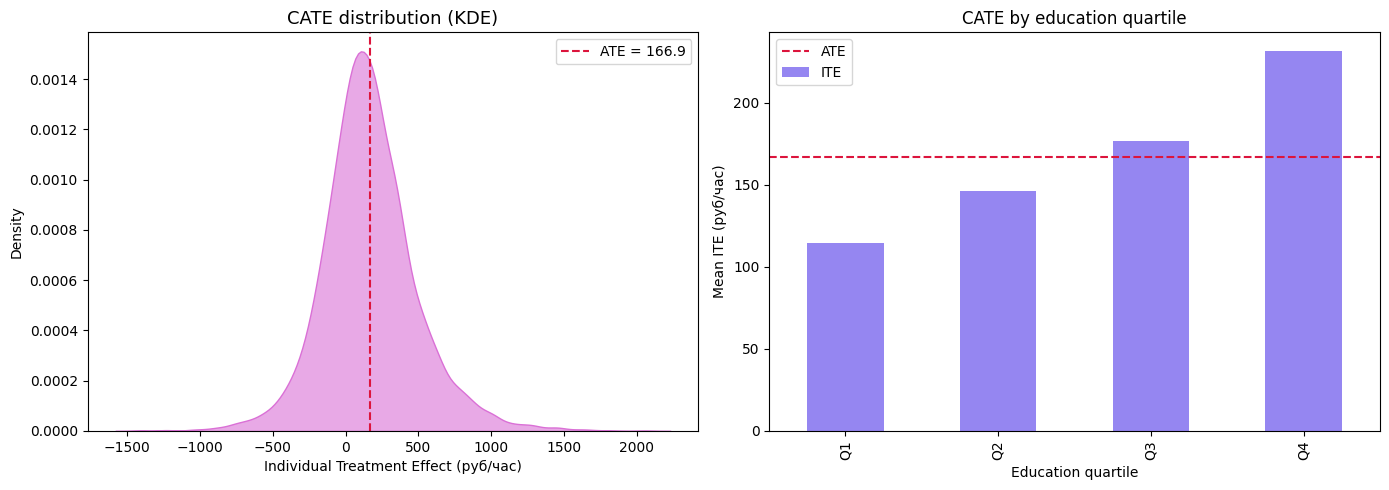

In [81]:
ITE_sample = ITE_o[idx_small]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(ITE_sample, ax=axes[0], fill=True, color='orchid', alpha=0.6)
axes[0].axvline(ATE_oracle, color='crimson', linestyle='--', label=f'ATE = {ATE_oracle:.1f}')
axes[0].set_title('CATE distribution (KDE)', fontsize=13)
axes[0].set_xlabel('Individual Treatment Effect (руб/час)')
axes[0].legend()

df_oracle_small = pd.DataFrame({
    'ITE': ITE_sample,
    'education': education_o[idx_small],
    'isAge50': isAge50_o[idx_small],
    'isMale': isMale_o[idx_small],
})
df_oracle_small['educ_q'] = pd.qcut(df_oracle_small['education'], 4, labels=['Q1','Q2','Q3','Q4'])
cate_by_educ = df_oracle_small.groupby('educ_q')['ITE'].mean()
cate_by_educ.plot(kind='bar', ax=axes[1], color='mediumslateblue', alpha=0.8)
axes[1].axhline(ATE_oracle, color='crimson', linestyle='--', label='ATE')
axes[1].set_title('CATE by education quartile')
axes[1].set_xlabel('Education quartile')
axes[1].set_ylabel('Mean ITE (руб/час)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [82]:
summary_oracle = pd.DataFrame({
    'Estimand': ['ATE', 'LATE'],
    'Oracle estimate (руб/час)': [ATE_oracle, LATE_oracle],
    'Population': ['All N=2M', f'Compliers ({compliers_mask.mean():.1%})'],
    'Interpretation': [
        'Avg wage gain for random person',
        'Wage gain for those induced by age50 instrument'
    ]
})
print(summary_oracle.to_string(index=False))

Estimand  Oracle estimate (руб/час)        Population                                  Interpretation
     ATE                 166.893575          All N=2M                 Avg wage gain for random person
    LATE                 164.402057 Compliers (32.2%) Wage gain for those induced by age50 instrument


## 5.3

In [83]:
treated   = full_df[full_df['training'] == 1]['wage']
untreated = full_df[full_df['training'] == 0]['wage']

naive_ate = treated.mean() - untreated.mean()
print(f"Naive ATE (difference in means): {naive_ate:.2f} руб/час")
print(f"Mean wage (treated):   {treated.mean():.2f}")
print(f"Mean wage (untreated): {untreated.mean():.2f}")

Naive ATE (difference in means): 450.42 руб/час
Mean wage (treated):   2583.74
Mean wage (untreated): 2133.31


## 5.4

In [84]:
best_clf = results['Logistic Regression']['model']
best_reg = reg_results['Linear Regression (OLS)']['model']

FEATURE_COLS     = ["isMale", "experience", "education", "isUrban", "isAge50"]
FEATURE_COLS_REG = ["isMale", "experience", "education", "isUrban", "isAge50"]

X_full = full_df[FEATURE_COLS].values
D_full = full_df['training'].values
Y_full = full_df['wage'].values

scaler_full = StandardScaler()
X_full_sc = scaler_full.fit_transform(X_full)

In [85]:
X_ols = np.column_stack([D_full, X_full])
ols = LinearRegression().fit(X_ols, Y_full)
ATE_ols = ols.coef_[0]
print(f"OLS ATE: {ATE_ols:.2f} руб/час")

OLS ATE: 320.11 руб/час


In [86]:
X_with_D = np.column_stack([D_full, X_full])
reg_model = reg_results['Linear Regression (OLS)']['model']

reg_model.fit(X_with_D, Y_full)

X1 = np.column_stack([np.ones(len(full_df)), X_full])   # D=1 для всех
X0 = np.column_stack([np.zeros(len(full_df)), X_full])   # D=0 для всех

ATE_ce = np.mean(reg_model.predict(X1) - reg_model.predict(X0))
print(f"Conditional Expectations ATE: {ATE_ce:.2f} руб/час")

Conditional Expectations ATE: 320.11 руб/час


In [87]:
ps = best_clf.predict_proba(X_full_sc)[:, 1]

eps = 1e-6
ps_clipped = np.clip(ps, eps, 1 - eps)

ipw_treated   =  D_full * Y_full / ps_clipped
ipw_untreated = (1 - D_full) * Y_full / (1 - ps_clipped)
ATE_ipw = np.mean(ipw_treated - ipw_untreated)
print(f"IPW ATE: {ATE_ipw:.2f} руб/час")

print(f"PS range: [{ps.min():.4f}, {ps.max():.4f}]")

IPW ATE: 367.75 руб/час
PS range: [0.4640, 0.8450]


In [88]:
mu1 = reg_model.predict(X1)
mu0 = reg_model.predict(X0)

dr_term = (mu1 - mu0 +
           D_full * (Y_full - mu1) / ps_clipped -
           (1 - D_full) * (Y_full - mu0) / (1 - ps_clipped))
ATE_dr = np.mean(dr_term)
print(f"Doubly Robust (AIPW) ATE: {ATE_dr:.2f} руб/час")

Doubly Robust (AIPW) ATE: 323.97 руб/час


In [89]:
Y_resid = Y_full - cross_val_predict(
    GradientBoostingRegressor(), X_full, Y_full, cv=5)

D_resid = D_full - cross_val_predict(
    GradientBoostingClassifier(), X_full, D_full, cv=5,
    method='predict_proba')[:, 1]

ATE_dml = np.cov(D_resid, Y_resid)[0,1] / np.var(D_resid)
print(f"Double ML ATE: {ATE_dml:.2f} руб/час")

Double ML ATE: 303.57 руб/час


In [90]:
ate_results = pd.DataFrame({
    'Method': ['Oracle', 'Naive DiM', 'OLS', 'Cond. Expectations',
               'IPW', 'Doubly Robust', 'Double ML'],
    'ATE (руб/час)': [ATE_oracle, naive_ate, ATE_ols,
                      ATE_ce, ATE_ipw, ATE_dr, ATE_dml]
})
ate_results['Bias vs Oracle'] = ate_results['ATE (руб/час)'] - ATE_oracle
print(ate_results.to_string(index=False))

            Method  ATE (руб/час)  Bias vs Oracle
            Oracle     166.893575        0.000000
         Naive DiM     450.424373      283.530798
               OLS     320.111782      153.218206
Cond. Expectations     320.111782      153.218206
               IPW     367.752196      200.858621
     Doubly Robust     323.970575      157.076999
         Double ML     303.568427      136.674852


## 5.5

In [91]:
X_interact = np.column_stack([
    D_full,
    X_full,
    D_full[:, None] * X_full
])
ols_interact = LinearRegression().fit(X_interact, Y_full)

cate_ols = (ols_interact.predict(np.column_stack([np.ones(N), X_full, X_full])) - ols_interact.predict(np.column_stack([np.zeros(N), X_full, np.zeros_like(X_full)])))

Xd1 = X_interact.copy(); Xd1[:,0] = 1; Xd1[:,6:] = X_full
Xd0 = X_interact.copy(); Xd0[:,0] = 0; Xd0[:,6:] = 0
cate_ols = ols_interact.predict(Xd1) - ols_interact.predict(Xd0)
print(f"OLS CATE — mean: {cate_ols.mean():.2f}, std: {cate_ols.std():.2f}")

OLS CATE — mean: 324.45, std: 121.58


In [92]:
s_model = RandomForestRegressor(n_estimators=200, random_state=42)
s_model.fit(np.column_stack([X_full, D_full]), Y_full)

cate_s = (s_model.predict(np.column_stack([X_full, np.ones(N)]))
        - s_model.predict(np.column_stack([X_full, np.zeros(N)])))
print(f"S-learner CATE — mean: {cate_s.mean():.2f}, std: {cate_s.std():.2f}")

S-learner CATE — mean: 264.86, std: 249.47


In [93]:
t1 = RandomForestRegressor(n_estimators=200, random_state=42)
t0 = RandomForestRegressor(n_estimators=200, random_state=42)

mask1 = D_full == 1
mask0 = D_full == 0

t1.fit(X_full[mask1], Y_full[mask1])
t0.fit(X_full[mask0], Y_full[mask0])

cate_t = t1.predict(X_full) - t0.predict(X_full)
print(f"T-learner CATE — mean: {cate_t.mean():.2f}, std: {cate_t.std():.2f}")

T-learner CATE — mean: 334.12, std: 365.17


In [94]:
ps_full = best_clf.predict_proba(X_full_sc)[:, 1]
ps_full_c = np.clip(ps_full, 1e-6, 1 - 1e-6)

Z_ct = Y_full * (D_full - ps_full_c) / (ps_full_c * (1 - ps_full_c))

ct_model = RandomForestRegressor(n_estimators=200, random_state=42)
ct_model.fit(X_full, Z_ct)
cate_ct = ct_model.predict(X_full)
print(f"Class Transform CATE — mean: {cate_ct.mean():.2f}, std: {cate_ct.std():.2f}")

Class Transform CATE — mean: 314.84, std: 3313.55


In [95]:
pseudo_1 = Y_full[mask1] - t0.predict(X_full[mask1])
pseudo_0 = t1.predict(X_full[mask0]) - Y_full[mask0]

x_model1 = RandomForestRegressor(n_estimators=200, random_state=42)
x_model0 = RandomForestRegressor(n_estimators=200, random_state=42)
x_model1.fit(X_full[mask1], pseudo_1)
x_model0.fit(X_full[mask0], pseudo_0)

cate_x = (ps_full_c * x_model0.predict(X_full)
        + (1 - ps_full_c) * x_model1.predict(X_full))
print(f"X-learner CATE — mean: {cate_x.mean():.2f}, std: {cate_x.std():.2f}")

X-learner CATE — mean: 324.49, std: 247.65


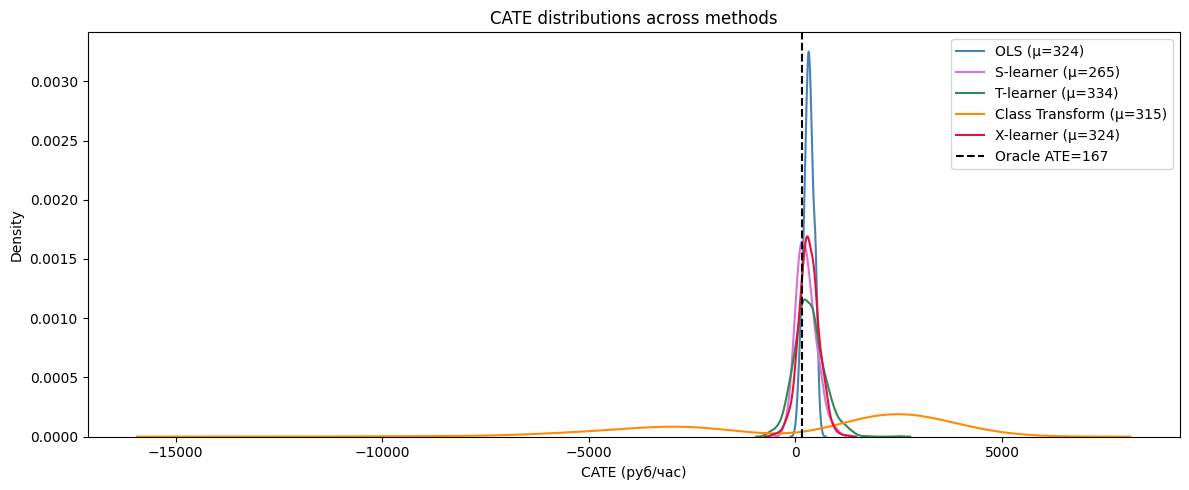

In [96]:
fig, ax = plt.subplots(figsize=(12, 5))
for cate, label, color in [
    (cate_ols, 'OLS', 'steelblue'),
    (cate_s,   'S-learner', 'orchid'),
    (cate_t,   'T-learner', 'seagreen'),
    (cate_ct,  'Class Transform', 'darkorange'),
    (cate_x,   'X-learner', 'crimson'),
]:
    sns.kdeplot(cate, ax=ax, label=f'{label} (μ={cate.mean():.0f})', color=color)

ax.axvline(ATE_oracle, color='black', linestyle='--', label=f'Oracle ATE={ATE_oracle:.0f}')
ax.set_xlabel('CATE (руб/час)')
ax.set_title('CATE distributions across methods')
ax.legend()
plt.tight_layout()
plt.show()

## 5.6

In [97]:
print(f"DML without IV (ATE): {ATE_dml:.2f} руб/час")

Z_full = full_df['isAge50'].values

CONTROLS = ["isMale", "experience", "education", "isUrban"]
X_ctrl = full_df[CONTROLS].values

Y_res_iv = Y_full - cross_val_predict(GradientBoostingRegressor(), X_ctrl, Y_full, cv=5)
D_res_iv = D_full - cross_val_predict(GradientBoostingClassifier(), X_ctrl, D_full, cv=5, method='predict_proba')[:, 1]
Z_res_iv = Z_full - cross_val_predict(GradientBoostingClassifier(), X_ctrl, Z_full, cv=5, method='predict_proba')[:, 1]

LATE_dml = np.cov(Z_res_iv, Y_res_iv)[0,1] / np.cov(Z_res_iv, D_res_iv)[0,1]
print(f"DML with IV (LATE): {LATE_dml:.2f} руб/час")

late_table = pd.DataFrame({
    'Method': ['Oracle LATE', 'DML without IV (≈ATE)', 'DML with IV (LATE)'],
    'Estimate (руб/час)': [LATE_oracle, ATE_dml, LATE_dml]
})
print(late_table.to_string(index=False))

DML without IV (ATE): 303.57 руб/час
DML with IV (LATE): 344.99 руб/час
               Method  Estimate (руб/час)
          Oracle LATE          164.402057
DML without IV (≈ATE)          303.568427
   DML with IV (LATE)          344.993064


## 5.7

In [99]:
worst_clf_name = "Naive Bayes"
worst_reg_name = "KNN Regressor"

worst_clf = results[worst_clf_name]['model']
worst_reg = reg_results[worst_reg_name]['model']

worst_scaled = results[worst_clf_name]['scaled']
X_worst_clf = X_full_sc if worst_scaled else X_full

ps_worst = worst_clf.predict_proba(X_worst_clf)[:, 1]
ps_worst_c = np.clip(ps_worst, 1e-6, 1 - 1e-6)

worst_reg_scaled = reg_results[worst_reg_name]['scaled']
X_worst_reg = X_full_sc if worst_reg_scaled else X_full

X_with_D = np.column_stack([X_full, D_full])
X_with_D_sc = np.column_stack([X_full_sc, D_full])

X1_worst = np.column_stack([X_full_sc if worst_reg_scaled else X_full, np.ones(N)])
X0_worst = np.column_stack([X_full_sc if worst_reg_scaled else X_full, np.zeros(N)])

worst_reg.fit(np.column_stack([X_worst_reg, D_full]), Y_full)
mu1_worst = worst_reg.predict(X1_worst)
mu0_worst = worst_reg.predict(X0_worst)

ATE_ipw_worst = np.mean(D_full * Y_full / ps_worst_c - (1 - D_full) * Y_full / (1 - ps_worst_c))

dr_worst = (mu1_worst - mu0_worst + D_full * (Y_full - mu1_worst) / ps_worst_c - (1 - D_full) * (Y_full - mu0_worst) / (1 - ps_worst_c))
ATE_dr_worst = np.mean(dr_worst)

Y_res_worst = Y_full - cross_val_predict(KNeighborsRegressor(**reg_results['KNN Regressor']['best_params']), X_full, Y_full, cv=5)

D_res_worst = D_full - cross_val_predict(KNeighborsClassifier(), X_full, D_full, cv=5, method='predict_proba')[:, 1]

ATE_dml_worst = np.cov(D_res_worst, Y_res_worst)[0,1] / np.var(D_res_worst)

comparison = pd.DataFrame({
    'Method': ['IPW', 'Doubly Robust', 'Double ML'],
    'ATE best (руб/час)': [ATE_ipw, ATE_dr, ATE_dml],
    'ATE worst (руб/час)': [ATE_ipw_worst, ATE_dr_worst, ATE_dml_worst],
    'Oracle (руб/час)': [ATE_oracle] * 3,
})
comparison['Δ best']  = comparison['ATE best (руб/час)']  - comparison['Oracle (руб/час)']
comparison['Δ worst'] = comparison['ATE worst (руб/час)'] - comparison['Oracle (руб/час)']

print(comparison.to_string(index=False))

       Method  ATE best (руб/час)  ATE worst (руб/час)  Oracle (руб/час)     Δ best    Δ worst
          IPW          367.752196           287.254340        166.893575 200.858621 120.360765
Doubly Robust          323.970575           291.967788        166.893575 157.076999 125.074213
    Double ML          303.568427           282.158095        166.893575 136.674852 115.264520
